In [1]:
import os

import torch

import pandas as pd 
import numpy as np

import sqlite3
import faiss

from sklearn.decomposition import PCA
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle

import plotly.graph_objects as go

from itertools import combinations

import joblib

ROOT = Path.cwd().parents[1]

EMBED_PATH = ROOT / "data/embeddings/base_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

IMAGE_DIR = ROOT / "images/ellipsoid" / EMBED_NAME
CACHE_DIR = ROOT / "data/cache" / EMBED_NAME
RESULTS_DIR = ROOT / "data/results" / EMBED_NAME

In [2]:
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [3]:
embeds = torch.load(EMBED_PATH, weights_only=False)
cls_tokens = embeds["cls_tokens"]
patches = embeds["patches"]

In [4]:
conn = sqlite3.connect(ROOT / "data/sql/metadata.db")

meta = pd.read_sql_query("SELECT * FROM meta", conn)
categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()
types_per_cat = pd.read_sql_query("""
    SELECT category, COUNT(DISTINCT type) AS num_types
    FROM meta
    GROUP BY category
""", conn)
max_types = types_per_cat["num_types"].max()

conn.close()

In [5]:
def load_or_compute(path, model_path, fn):
    if path.exists() and model_path.exists():
        print("Loading ", path)
        return np.load(path), joblib.load(model_path)
    
    print("Computing ", path)
    coords, model = fn()
    
    np.save(path, coords)
    joblib.dump(model, model_path)
    return coords, model

In [6]:
def compute_pca():
    pca = PCA(n_components=2)
    coords = pca.fit_transform(cls_tokens)
    return coords, pca

Loading  c:\projects\bursary\data\cache\base_embeds\cls_pca.npy


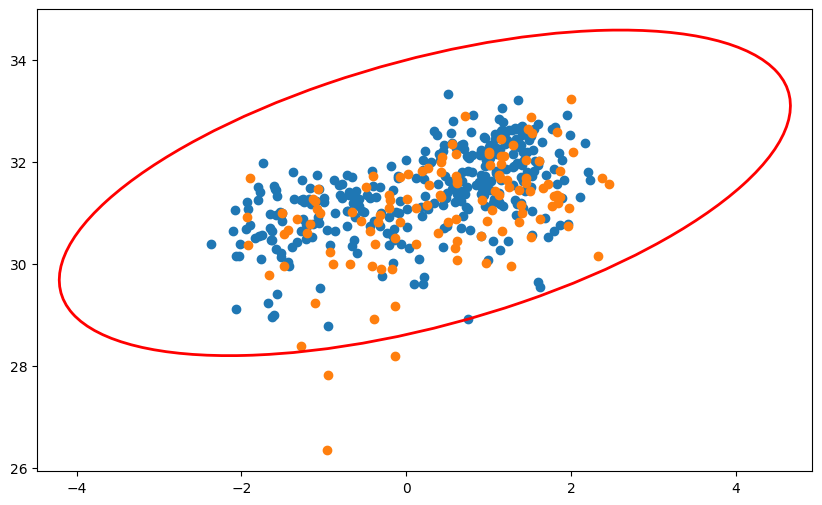

In [7]:
train_mask = meta["split"] == "train"
train_meta = meta[train_mask]
test_meta = meta[~train_mask]

train_cat_mask = train_meta["category"] == "screw"
test_cat_mask = (test_meta["category"] == "screw") & (test_meta["type"] != "good")

pca_2d, pca = load_or_compute(CACHE_DIR / "cls_pca.npy", CACHE_DIR / "pca.joblib", compute_pca)
pca_train = pca_2d[train_mask]
pca_test = pca_2d[~train_mask]

train_2d = pca_train[train_cat_mask]
test_2d = pca_test[test_cat_mask]

center = train_2d.mean(axis=0)

cov = np.cov(train_2d.T)
cov += np.eye(cov.shape[0]) * 1e-6
cov_inv = np.linalg.pinv(cov)

diff = train_2d - center
d2 = np.einsum("ij, jk, ik->i", diff, cov_inv, diff)

ch2 = d2.max()

eigvals, eigvecs = np.linalg.eigh(cov)

order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

width = 2 * np.sqrt(eigvals[0] * ch2)
height = 2 * np.sqrt(eigvals[1] * ch2)

angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=train_2d[:, 0], y=train_2d[:, 1])
ax.scatter(x=test_2d[:, 0], y=test_2d[:, 1])

ellipse = Ellipse(
    xy=center,
    width=width,
    height=height,
    angle=angle,
    edgecolor="red",
    facecolor="none",
    linewidth=2
)

ax.add_patch(ellipse)
plt.show()

Cat length:  320
frac: 0.025
K: 10
most compact idx: 72
avg KNN dist: 53.648388
frac: 0.05
K: 16
most compact idx: 72
avg KNN dist: 59.03626
frac: 0.1
K: 32
most compact idx: 72
avg KNN dist: 73.150925


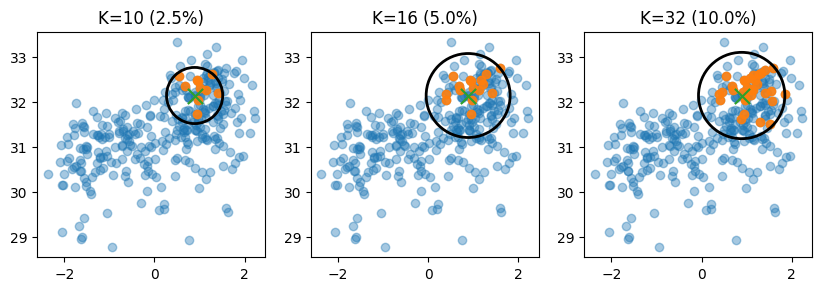

In [8]:
train_emb = cls_tokens[train_mask]
cat_emb = train_emb[train_cat_mask]
pca_cat = pca_train[train_cat_mask]

print("Cat length: ", len(cat_emb))

fig, axes = plt.subplots(1, 3, figsize=(10, 6))

for i, frac in enumerate([0.025, 0.05, 0.10]):
    K = max(10, int(frac * len(cat_emb)))

    index = faiss.IndexFlatL2(cat_emb.shape[1])
    index.add(cat_emb.astype("float32"))

    D, I = index.search(
        cat_emb.astype("float32"),
        k=K+1 # Nearest is itself
    )

    D = D[:, 1:]    # Remove self
    I = I[:, 1:]

    avg_knn = D.mean(axis=1)

    most_compact_idx = avg_knn.argmin()
    neighbours = I[most_compact_idx]
    
    center_2d = pca_cat[most_compact_idx]

    neighbours_2d = pca_cat[neighbours]
    radius_2d = np.linalg.norm(neighbours_2d - center_2d, axis=1).max()

    ax = axes[i]
    ax.scatter(pca_cat[:, 0], pca_cat[:, 1], alpha=0.4)
    ax.scatter(neighbours_2d[:, 0], neighbours_2d[:, 1], alpha=0.9)
    ax.scatter(center_2d[0], center_2d[1], marker="x", s=120)

    circle = Circle(
        center_2d,
        radius_2d,
        fill=False,
        linewidth=2
    )

    ax.add_patch(circle)
    ax.set_title(f"K={K} ({frac*100:.1f}%)")
    ax.set_aspect("equal", adjustable="box")

    print("frac:", frac)
    print("K:", K)
    print("most compact idx:", most_compact_idx)
    print("avg KNN dist:", avg_knn[most_compact_idx])

plt.show()


Cat length:  320
RUN:  1
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (17, 2)
Growth:  1.0
RUN:  1
RUN:  2
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (18, 2)
Growth:  1.025
RUN:  1
RUN:  2
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (20, 2)
Growth:  1.05
RUN:  1
RUN:  2
RUN:  3
RUN:  4
RUN:  5
RUN:  6
RUN:  7
RUN:  8
RUN:  9
RUN:  10
RUN:  11
RUN:  12
RUN:  13
RUN:  14
RUN:  15
RUN:  16
RUN:  17
RUN:  18
K: 16
Neighbours Shape:  (16, 2)
Covered Shape:  (320, 2)
Growth:  1.1


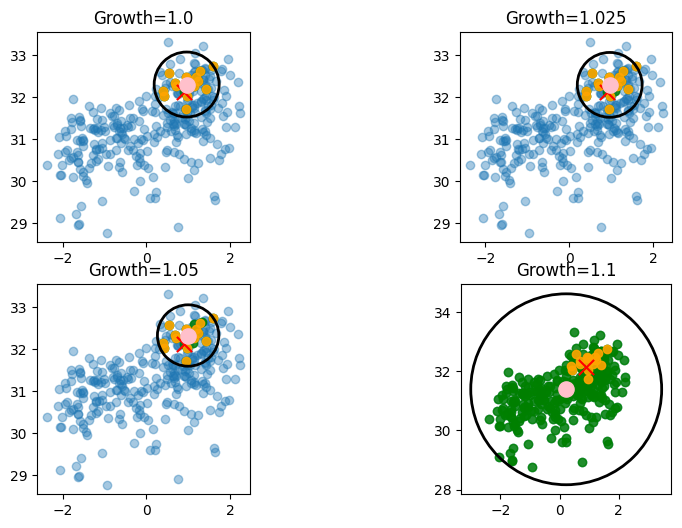

In [9]:
train_emb = cls_tokens[train_mask]
cat_emb = train_emb[train_cat_mask]
pca_cat = pca_train[train_cat_mask]

print("Cat length: ", len(cat_emb))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

K = max(10, int(0.05 * len(cat_emb)))

index = faiss.IndexFlatL2(cat_emb.shape[1])
index.add(cat_emb.astype("float32"))

D, I = index.search(
    cat_emb.astype("float32"),
    k=K+1 # Nearest is itself
)

D = D[:, 1:]    # Remove self
I = I[:, 1:]

avg_knn = D.mean(axis=1)

most_compact_idx = avg_knn.argmin()
neighbours = I[most_compact_idx]

center = cat_emb[most_compact_idx]
radius = np.sqrt(D[most_compact_idx, -1])

distances = np.linalg.norm(cat_emb - center, axis=1)

covered_mask = distances <= radius
covered_idx = np.where(covered_mask)[0]


for i, growth in enumerate([1.00, 1.025, 1.05, 1.10]):
    ax = axes[i]

    j = 1
    while True:
        print("RUN: ", j)
        centroid = cat_emb[covered_idx].mean(axis=0)

        radius = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()
        radius *= growth

        distances = np.linalg.norm(cat_emb - centroid, axis=1)
        new_covered_idx = np.where(distances <= radius)[0]

        if np.array_equal(np.sort(new_covered_idx), np.sort(covered_idx)):
            break

        covered_idx = new_covered_idx
        j += 1

    centroid = cat_emb[covered_idx].mean(axis=0)
    radius = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()

    centroid_2d = pca.transform(centroid.reshape(1, -1))[0]
    center_2d = pca_cat[most_compact_idx]

    neighbours_2d = pca_cat[neighbours]
    covered_2d = pca_cat[covered_idx]

    radius_2d = np.linalg.norm(covered_2d - centroid_2d, axis=1).max()

    ax.scatter(pca_cat[:, 0], pca_cat[:, 1], alpha=0.4)
    ax.scatter(covered_2d[:, 0], covered_2d[:, 1], alpha=0.8, color="green")
    ax.scatter(neighbours_2d[:, 0], neighbours_2d[:, 1], alpha=0.9, color="orange")
    ax.scatter(center_2d[0], center_2d[1], marker="x", s=120, color="red")
    ax.scatter(centroid_2d[0], centroid_2d[1], marker="o", s=120, color="pink")

    circle = Circle(
        centroid_2d,
        radius_2d,
        fill=False,
        linewidth=2
    )

    ax.add_patch(circle)
    ax.set_title(f"Growth={growth}")
    ax.set_aspect("equal", adjustable="box")

    print("K:", K)

    print("Neighbours Shape: ", neighbours_2d.shape)
    print("Covered Shape: ", covered_2d.shape)

    print("Growth: ", growth)

plt.show()

In [10]:
uncovered_mask = np.ones(len(cat_emb), dtype=bool)
spheres = []

K_frac = 0.05

start_growth = 1.05
min_growth = 1

while uncovered_mask.any():
    uncovered_idx = np.where(uncovered_mask)[0]
    uncovered_emb = cat_emb[uncovered_idx].astype("float32")

    K = max(2, int(K_frac * len(uncovered_idx)))
    K = min(K, len(uncovered_idx) - 1)

    growth = max(min_growth, start_growth - 0.0025 * len(spheres))
    if K < 1:
        covered_idx = uncovered_idx
        centroid = cat_emb[covered_idx].mean(axis=0)
        radius = 0.0
    else:
        index = faiss.IndexFlatL2(uncovered_emb.shape[1])
        index.add(uncovered_emb)

        D, I = index.search(uncovered_emb.astype("float32"), k=K+1) # +1 as nearest is itself 

        D = D[:, 1:]    # Remove self
        I = I[:, 1:]

        avg_knn = D.mean(axis=1)

        local_compact  = avg_knn.argmin()
        neighbours_local = I[local_compact]

        covered_idx = uncovered_idx[np.r_[local_compact, neighbours_local]]

        no_growth_steps = 0

        while True:
            old_covered_idx = covered_idx.copy()

            centroid = cat_emb[covered_idx].mean(axis=0)

            base_radius = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()
            search_radius = base_radius * growth

            distances = np.linalg.norm(cat_emb - centroid, axis=1)
            candidate_idx = np.where(distances <= search_radius)[0]

            shared_count = np.sum(~uncovered_mask[candidate_idx])
            if shared_count > 0:
                break

            new_covered_idx = candidate_idx[uncovered_mask[candidate_idx]]

            if np.array_equal(np.sort(new_covered_idx), np.sort(old_covered_idx)):
                break

            covered_idx = new_covered_idx

        centroid = cat_emb[covered_idx].mean(axis=0)
        radius = np.linalg.norm(cat_emb[covered_idx] - centroid, axis=1).max()

    spheres.append({
        "center": centroid,
        "radius": radius,
        "covered_idx": covered_idx
    })

    uncovered_mask[covered_idx] = False
    
    print(
        f"Sphere {len(spheres)} | "
        f"covered={len(covered_idx)} | "
        f"remaining={uncovered_mask.sum()} | "
        f"radius={radius:.4f}"
    )

Sphere 1 | covered=20 | remaining=300 | radius=7.3900
Sphere 2 | covered=20 | remaining=280 | radius=8.8042
Sphere 3 | covered=31 | remaining=249 | radius=9.1899
Sphere 4 | covered=13 | remaining=236 | radius=8.9855
Sphere 5 | covered=29 | remaining=207 | radius=12.1457
Sphere 6 | covered=20 | remaining=187 | radius=9.3477
Sphere 7 | covered=10 | remaining=177 | radius=7.8027
Sphere 8 | covered=9 | remaining=168 | radius=8.0446
Sphere 9 | covered=9 | remaining=159 | radius=7.5066
Sphere 10 | covered=8 | remaining=151 | radius=7.5600
Sphere 11 | covered=8 | remaining=143 | radius=7.6182
Sphere 12 | covered=8 | remaining=135 | radius=7.4823
Sphere 13 | covered=7 | remaining=128 | radius=7.0335
Sphere 14 | covered=7 | remaining=121 | radius=8.4840
Sphere 15 | covered=7 | remaining=114 | radius=7.6173
Sphere 16 | covered=6 | remaining=108 | radius=7.7188
Sphere 17 | covered=6 | remaining=102 | radius=8.1183
Sphere 18 | covered=6 | remaining=96 | radius=8.6375
Sphere 19 | covered=5 | remain

In [11]:
overlaps = []

for i, j in combinations(range(len(spheres)), 2):
    c1 = spheres[i]["center"]
    c2 = spheres[j]["center"]

    r1 = spheres[i]["radius"]
    r2 = spheres[j]["radius"]

    centre_dist = np.linalg.norm(c1 - c2)
    overlap_amount = (r1+r2) - centre_dist
    
    dist_to_c1 = np.linalg.norm(cat_emb[spheres[j]["covered_idx"]] - c1, axis=1) 
    dist_to_c2 = np.linalg.norm(cat_emb[spheres[i]["covered_idx"]] - c2, axis=1) 

    c1_overlap_count = np.sum(dist_to_c1 <= r1)
    c2_overlap_count = np.sum(dist_to_c2 <= r2)

    overlaps.append({
        "sphere_i": i,
        "sphere_j": j,
        "centre_dist": centre_dist,
        "add_radii": r1 + r2,
        "overlap": overlap_amount > 0,
        "overlap_amount": max(0, overlap_amount),
        "j_points_inside_i": c1_overlap_count,
        "i_points_inside_j": c2_overlap_count
    })

overlap_df = pd.DataFrame(overlaps)

overlap_df.to_csv(RESULTS_DIR / "sphere_overlaps.csv")
overlap_df

,sphere_i,sphere_j,centre_dist,add_radii,overlap,overlap_amount,j_points_inside_i,i_points_inside_j
0,0,1,16.673229,16.194168,False,0.000000,0,0
1,0,2,17.587193,16.579832,False,0.000000,0,0
2,0,3,15.394529,16.375500,True,0.980970,0,0
3,0,4,11.920086,19.535648,True,7.615562,0,1
4,0,5,9.724252,16.737640,True,7.013389,0,0
...,...,...,...,...,...,...,...,...
1030,42,44,22.500515,22.697514,True,0.196999,0,0
1031,42,45,23.449812,25.333302,True,1.883490,0,0
1032,43,44,15.840261,23.578426,True,7.738166,0,0
1033,43,45,20.196207,26.214214,True,6.018007,0,0


In [12]:
num_overlap = overlap_df["overlap"].sum()

num_overlap

np.int64(313)

In [20]:
overlapped_points = set()

for _, row in overlap_df.iterrows():
    i = int(row["sphere_i"])
    j = int(row["sphere_j"])

    # points owned by j that are inside i
    dist_j_to_i = np.linalg.norm(cat_emb[spheres[j]["covered_idx"]] - spheres[i]["center"], axis=1)
    overlapped_points.update(spheres[j]["covered_idx"][dist_j_to_i <= spheres[i]["radius"]])

    # points owned by i that are inside j
    dist_i_to_j = np.linalg.norm(cat_emb[spheres[i]["covered_idx"]] - spheres[j]["center"], axis=1)
    overlapped_points.update(spheres[i]["covered_idx"][dist_i_to_j <= spheres[j]["radius"]])

len(overlapped_points), len(overlapped_points) / len(cat_emb)

(92, 0.2875)

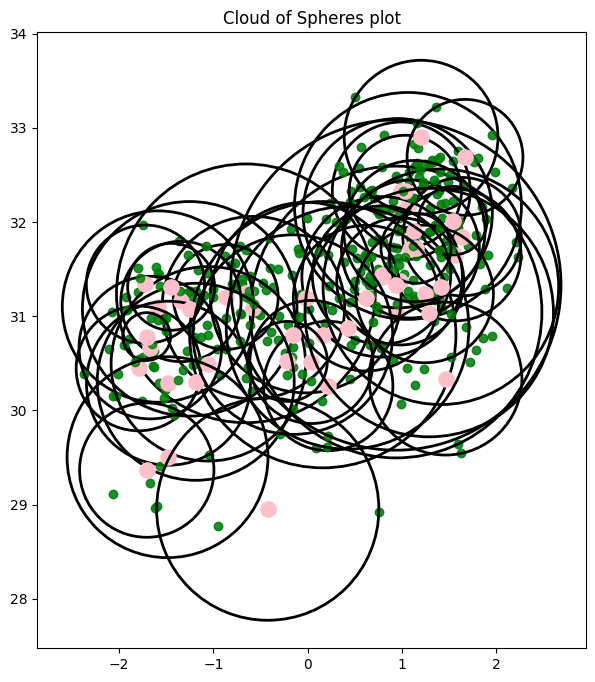

In [13]:
fig, ax = plt.subplots(figsize=(18, 8))

ax.scatter(pca_cat[:, 0], pca_cat[:, 1], alpha=0.4)

for sphere in spheres:
    centroid = sphere["center"]
    covered_idx = sphere["covered_idx"]

    centroid_2d = pca.transform(centroid.reshape(1, -1))[0]
    covered_2d = pca_cat[covered_idx]

    radius_2d = np.linalg.norm(covered_2d - centroid_2d, axis=1).max()

    ax.scatter(covered_2d[:, 0], covered_2d[:, 1], alpha=0.8, color="green")
    ax.scatter(centroid_2d[0], centroid_2d[1], marker="o", s=120, color="pink")

    circle = Circle(
        centroid_2d,
        radius_2d,
        fill=False,
        linewidth=2
    )

    ax.add_patch(circle)

ax.set_title("Cloud of Spheres plot")
ax.set_aspect("equal", adjustable="box")

plt.show()

In [14]:
def sphere_surface(center, radius, resolution=20):
    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)

    x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
    y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
    z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

    return x, y, z

In [15]:
pca3 = PCA(n_components=3)
pca_3d = pca3.fit_transform(cls_tokens)

pca_train_3d = pca_3d[train_mask]
pca_cat_3d = pca_train_3d[train_cat_mask]

In [16]:
rng = np.random.default_rng(42)

colours = [
    f"rgb({r},{g},{b})"
    for r, g, b in rng.integers(30, 255, size=(len(spheres), 3))
]

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=pca_cat_3d[:, 0],
    y=pca_cat_3d[:, 1],
    z=pca_cat_3d[:, 2],
    mode="markers",
    marker=dict(size=3, opacity=0.35),
    name="all screw train"
))

for i, s in enumerate(spheres):
    idx = s["covered_idx"]
    pts = pca_cat_3d[idx]

    center_3d = pts.mean(axis=0)
    radius_3d = np.linalg.norm(pts - center_3d).max()

    fig.add_trace(go.Scatter3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        mode="markers",
        marker=dict(size=4, color=colours[i]),
        name=f"sphere {i+1}",
        legendgroup=f"sphere{i}"
    ))

    fig.add_trace(go.Scatter3d(
        x=[center_3d[0]],
        y=[center_3d[1]],
        z=[center_3d[2]],
        mode="markers",
        marker=dict(size=7, symbol="x", color=colours[i]),
        name=f"center {i+1}",
        showlegend=False,
        legendgroup=f"sphere{i}"
    ))

    xs, ys, zs = sphere_surface(center_3d, radius_3d, resolution=20)

    fig.add_trace(go.Surface(
        x=xs,
        y=ys,
        z=zs,
        opacity=0.12,
        showscale=False,
        name=f"Boundary {i+1}",
        legendgroup=f"sphere{i}",
        showlegend=False
    ))

fig.update_layout(
    title="3D PCA multi-sphere assignment view",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    ),
    width=900,
    height=750,
    updatemenus=[
    dict(
        type="buttons",
        buttons=[
            dict(
                label="Show All",
                method="update",
                args=[{"visible": [True] * len(fig.data)}]
            ),
            dict(
                label="Hide All",
                method="update",
                args=[{"visible": ["legendonly"] * len(fig.data)}]
            )
        ],
        x=1.15,
        y=0
    )
    ]
)

fig.show()